# Predict Calorie Expenditure

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
from catboost import CatBoostRegressor
from lightautoml.automl.presets.tabular_presets import (
    TabularAutoML,
    TabularUtilizedAutoML,
)
from lightautoml.tasks import Task
from lightgbm import LGBMRegressor
from optuna.samplers import TPESampler
from scipy import stats
from sklearn.compose import ColumnTransformer
from sklearn.metrics import root_mean_squared_log_error
from sklearn.model_selection import KFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

d:\GitHub\itmo-automl\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'nlp' extra dependency package 'fasttext-numpy2' isn't installed. Look at README.md in repo 'LightAutoML' for installation instructions.
'nlp' extra dependency package 'nltk' isn't installed. Look at README.md in repo 'LightAutoML' for installation instructions.


d:\GitHub\itmo-automl\.venv\Lib\site-packages\lightautoml\text\tokenizer.py:21: UserWarning: 'nltk' - package isn't installed
  warnings.warn("'nltk' - package isn't installed")
d:\GitHub\itmo-automl\.venv\Lib\site-packages\lightautoml\transformers\text.py:23: UserWarning: 'fasttext' - package isn't installed
  warnings.warn("'fasttext' - package isn't installed")


## Загрузка и анализ данных (EDA)

In [2]:
train_df = pd.read_csv('./data/train.csv')
test_df = pd.read_csv('./data/test.csv')

train_df.tail()

,id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
749995,749995,male,28,193.0,97.0,30.0,114.0,40.9,230.0
749996,749996,female,64,165.0,63.0,18.0,92.0,40.5,96.0
749997,749997,male,60,162.0,67.0,29.0,113.0,40.9,221.0
749998,749998,male,45,182.0,91.0,17.0,102.0,40.3,109.0
749999,749999,female,39,171.0,65.0,19.0,97.0,40.6,103.0


Колонки:
- id записи, совпадает с индексом строки
- Sex - пол (мужской / женской)
- Age - возраст, полных лет
- Height - рост, см.
- Weight - вес, кг.
- Duration - длительность физ. нагрузки
- Heart_Rate - пульс во время физ. нагрузки
- Body_Temp - температура тела во время физ. нагрузки
- Calories - затраченные калории, целевая переменная

### Целевая переменная

In [3]:
target_col = 'Calories'
target_stats = (
    train_df[target_col]
    .describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
    .to_frame(name='Calories')
)
target_stats.loc['iqr'] = target_stats.loc['75%'] - target_stats.loc['25%']
target_stats

,Calories
count,750000.000000
mean,88.282781
std,62.395349
min,1.000000
5%,8.000000
25%,34.000000
50%,77.000000
75%,136.000000
95%,200.000000
max,314.000000


In [4]:
print(
    'Кол-во записей меньше 5% перцентиля:',
    (train_df[target_col] < target_stats.loc['5%'][0]).sum(),
)
print(
    'Кол-во записей больше 95% перцентиля:',
    (train_df[target_col] > target_stats.loc['95%'][0]).sum(),
)

Кол-во записей меньше 5% перцентиля: 32080
Кол-во записей больше 95% перцентиля: 37086


In [5]:
print('Пропуски:', train_df[target_col].isna().sum())
print('Нулевые значения:', (train_df[target_col] == 0).sum())

Пропуски: 0
Нулевые значения: 0


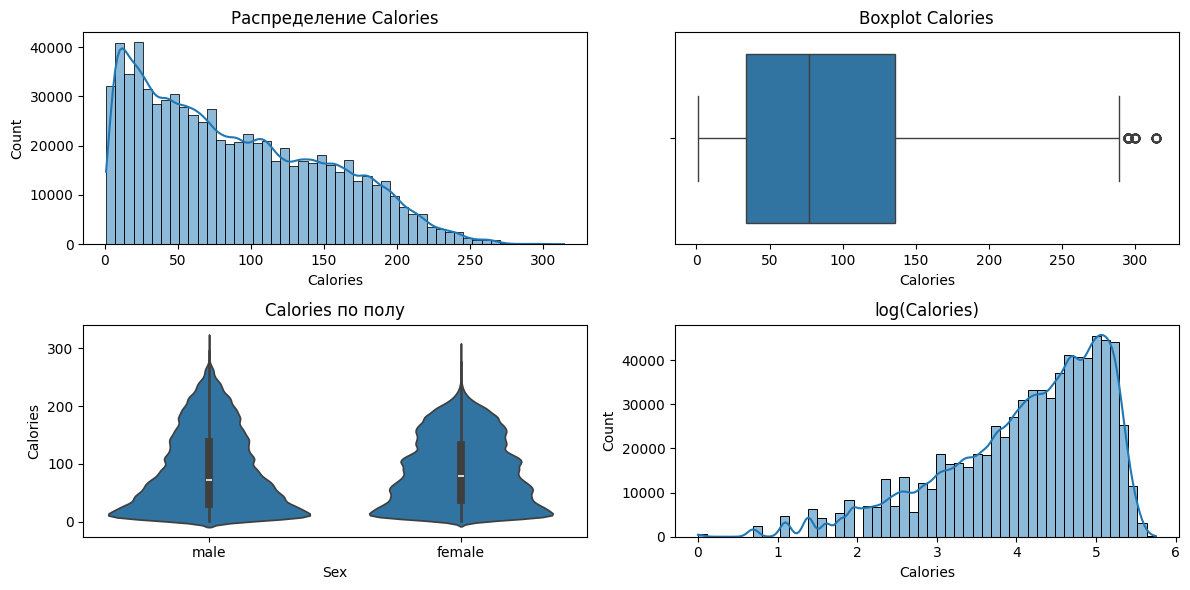

In [6]:
plt.figure(figsize=(12, 6))

plt.subplot(2, 2, 1)
sns.histplot(train_df[target_col], bins=50, kde=True)  # type: ignore
plt.title('Распределение Calories')

plt.subplot(2, 2, 2)
sns.boxplot(x=train_df[target_col])
plt.title('Boxplot Calories')

plt.subplot(2, 2, 3)
sns.violinplot(train_df, x='Sex', y=target_col)
plt.title('Calories по полу')
plt.tight_layout()

plt.subplot(2, 2, 4)
sns.histplot(np.log(train_df[target_col]), bins=50, kde=True)
plt.title('log(Calories)')

plt.tight_layout()
plt.show()

У распределения Calories есть не очень длинное, но "тяжелое" плечо в правую сторону
от медианы. Фичей мало и они естественно ограничены сверху, поэтому достаточно
провести несложный анализ и преобразавания, сконцентрировавшись на генерации новых
признаков и обучении моделей.

На странице соревнования на Kaggle указано, что датасет сгенерирован
на основе данных [Calories Burnt Prediction](https://www.kaggle.com/datasets/ruchikakumbhar/calories-burnt-prediction),
однако других деталей и подробностей найти не удалось. Утверждается, что некоторые
распределения чуть отличаются, поэтому объединять два датасета смысла не вижу.

### Признаки

In [7]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 9 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   id          750000 non-null  int64  
 1   Sex         750000 non-null  object 
 2   Age         750000 non-null  int64  
 3   Height      750000 non-null  float64
 4   Weight      750000 non-null  float64
 5   Duration    750000 non-null  float64
 6   Heart_Rate  750000 non-null  float64
 7   Body_Temp   750000 non-null  float64
 8   Calories    750000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 51.5+ MB


In [8]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   id          250000 non-null  int64  
 1   Sex         250000 non-null  object 
 2   Age         250000 non-null  int64  
 3   Height      250000 non-null  float64
 4   Weight      250000 non-null  float64
 5   Duration    250000 non-null  float64
 6   Heart_Rate  250000 non-null  float64
 7   Body_Temp   250000 non-null  float64
dtypes: float64(5), int64(2), object(1)
memory usage: 15.3+ MB


In [9]:
numeric_cols = (
    train_df.select_dtypes(include=np.number).columns.drop(['id', target_col]).tolist()
)
categorical_cols = train_df.select_dtypes(exclude=np.number).columns.tolist()
features_cols = numeric_cols + categorical_cols

dtypes_summary = pd.DataFrame(
    {
        'feature': features_cols,
        'dtype': [train_df[col].dtype for col in features_cols],
        'n_unique': [train_df[col].nunique() for col in features_cols],
        'missing': [train_df[col].isna().sum() for col in features_cols],
    }
).sort_values('dtype')
dtypes_summary

,feature,dtype,n_unique,missing
0,Age,int64,60,0
1,Height,float64,86,0
2,Weight,float64,91,0
3,Duration,float64,30,0
4,Heart_Rate,float64,63,0
5,Body_Temp,float64,75,0
6,Sex,object,2,0


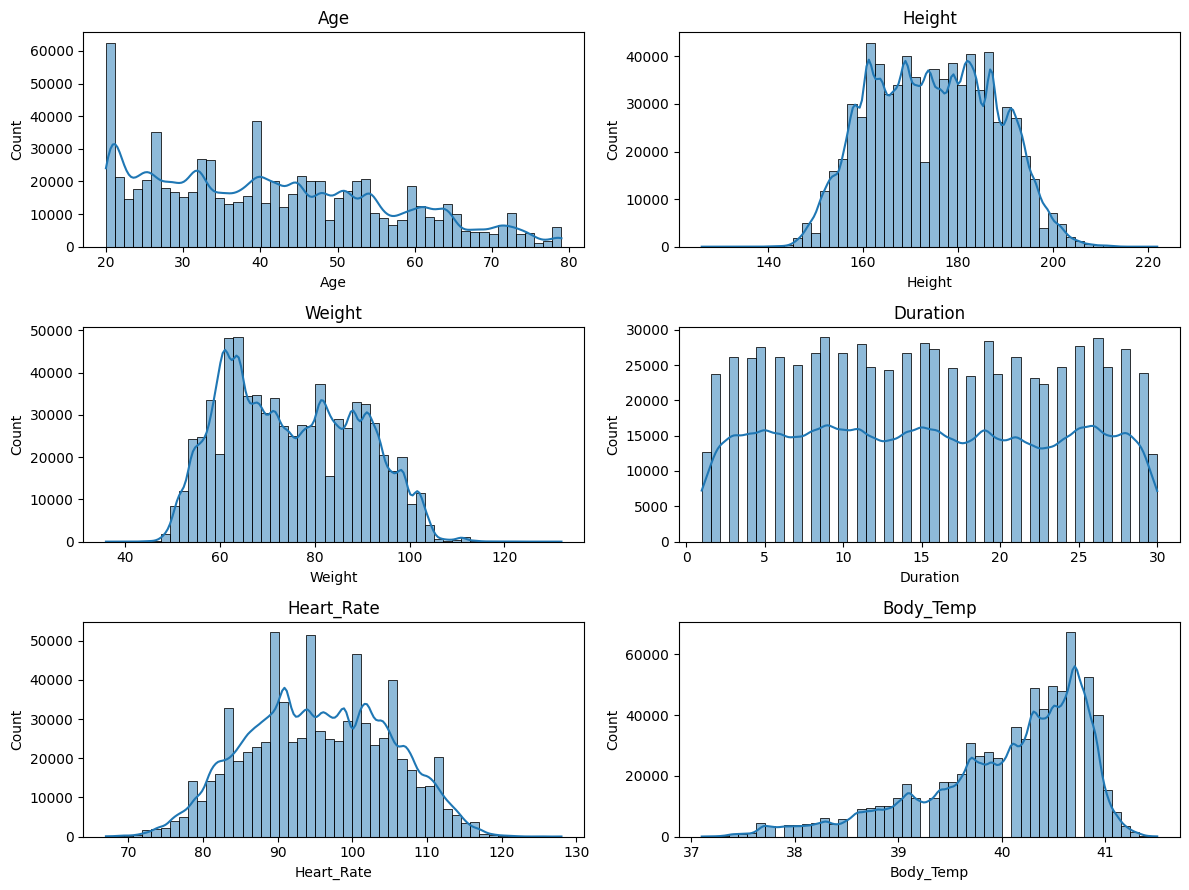

In [10]:
n = len(numeric_cols)
rows = (n + 1) // 2

fig, axes = plt.subplots(rows, 2, figsize=(12, 3 * rows))
axes_flat = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(train_df[col], bins=50, kde=True, ax=axes_flat[i])  # type: ignore
    axes_flat[i].set_title(col)

plt.tight_layout()
plt.show()

Скорее всего, в источнике данных были следующие ограничения:
- возраст 18-80 лет, данные немного перекошены к молодым респондентам
- рост 140-220 см., нормальное распределение
- вес 50-120 кг., небольшой перекос около 60 кг.
- длительность до 30 единиц, вероятно сек., равномерно распределены
- пульс 70-120 уд./сек., кардио зона, нормальное распределение
- темп. тела слегка повышенная, до 41.5'C, перекос ближе к 40'C

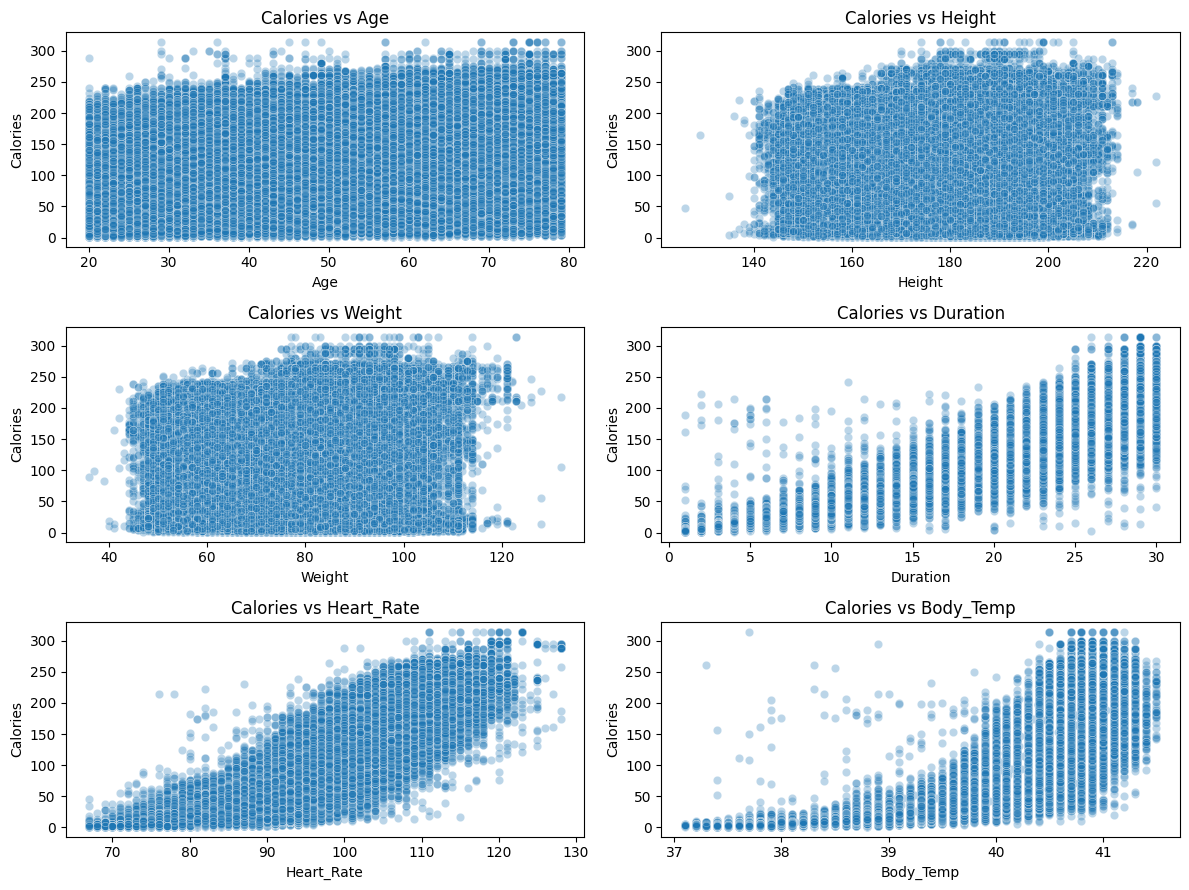

In [11]:
fig, axes = plt.subplots(rows, 2, figsize=(12, 3 * rows))
axes_flat = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.scatterplot(
        data=train_df,
        x=col,
        y=target_col,
        alpha=0.3,
        ax=axes_flat[i],
    )
    axes_flat[i].set_title(f'Calories vs {col}')

plt.tight_layout()
plt.show()

Наблюдается отсутствие корреляции затраченных калорий с возрастом, ростом и весом.
Можно разделить их на бины и проверить распределения калорий в каждом. Длительность
упражнения, пульс и темп. тела ожидаемо коррелируют с целевой переменной.

Гипотезы и новые признаки:
- индекс массы тела [BMI](https://en.wikipedia.org/wiki/Body_mass_index): Weight
/ (Height/100)^2 - индекс массы тела, влияет на энергорасход
- пульсовая зона (% от макс. возрастного): Heart_Rate / (220 - Age)
- бининг фичей возраст, рост и вес

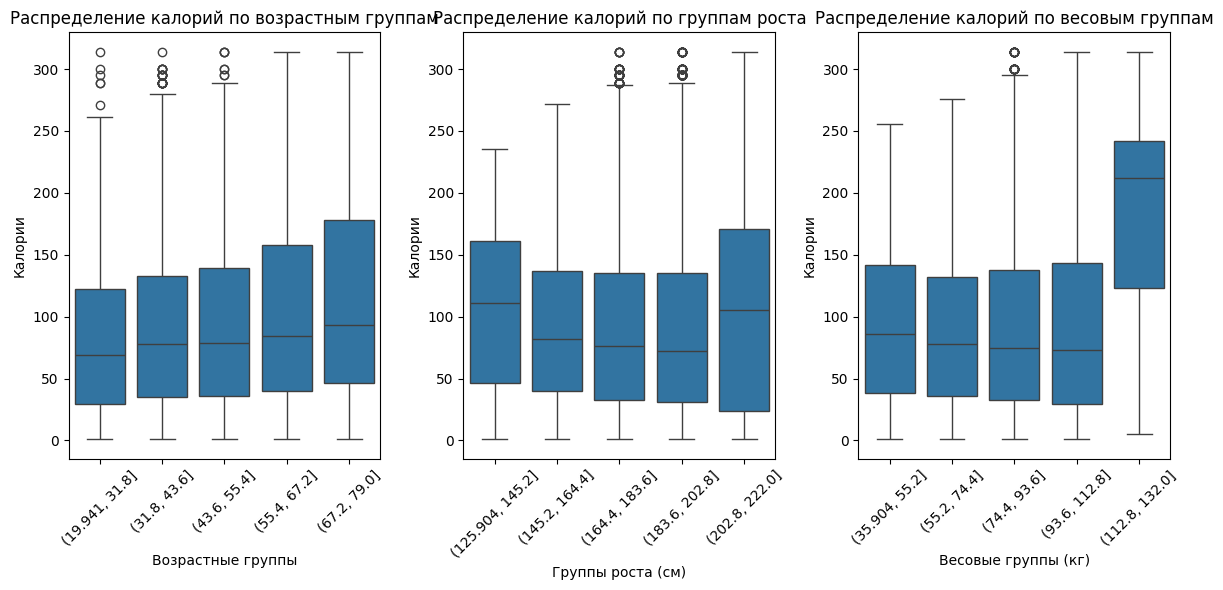

Среднее количество калорий по возрастным группам:
                      mean        std   count
Age_bin                                      
(19.941, 31.8]   78.529043  56.105068  238924
(31.8, 43.6]     87.600402  59.890565  195339
(43.6, 55.4]     89.524422  61.918960  169377
(55.4, 67.2]     99.954192  69.499662   99698
(67.2, 79.0]    111.637457  76.643658   46662

Среднее количество калорий по группам роста:
                        mean        std   count
Height_bin                                     
(125.904, 145.2]  106.366972  65.660958     545
(145.2, 164.4]     90.055676  58.060183  194267
(164.4, 183.6]     87.116173  61.780110  345132
(183.6, 202.8]     88.071119  66.628975  205557
(202.8, 222.0]    108.703267  81.237359    4499

Среднее количество калорий по весовым группам:
                      mean        std   count
Weight_bin                                   
(35.904, 55.2]   90.798122  58.957833   46761
(55.2, 74.4]     86.495081  57.924039  336379
(74.4, 93.6]  

In [12]:
train_copy = train_df.copy()

train_copy['Age_bin'] = pd.cut(train_copy['Age'], bins=5)
train_copy['Height_bin'] = pd.cut(train_copy['Height'], bins=5)
train_copy['Weight_bin'] = pd.cut(train_copy['Weight'], bins=5)

fig, axes = plt.subplots(1, 3, figsize=(12, 6))

sns.boxplot(data=train_copy, x='Age_bin', y='Calories', ax=axes[0])
axes[0].set_title('Распределение калорий по возрастным группам')
axes[0].set_xlabel('Возрастные группы')
axes[0].set_ylabel('Калории')
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(data=train_copy, x='Height_bin', y='Calories', ax=axes[1])
axes[1].set_title('Распределение калорий по группам роста')
axes[1].set_xlabel('Группы роста (см)')
axes[1].set_ylabel('Калории')
axes[1].tick_params(axis='x', rotation=45)

sns.boxplot(data=train_copy, x='Weight_bin', y='Calories', ax=axes[2])
axes[2].set_title('Распределение калорий по весовым группам')
axes[2].set_xlabel('Весовые группы (кг)')
axes[2].set_ylabel('Калории')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print('Среднее количество калорий по возрастным группам:')
print(train_copy.groupby('Age_bin')['Calories'].agg(['mean', 'std', 'count']))

print('\nСреднее количество калорий по группам роста:')
print(train_copy.groupby('Height_bin')['Calories'].agg(['mean', 'std', 'count']))

print('\nСреднее количество калорий по весовым группам:')
print(train_copy.groupby('Weight_bin')['Calories'].agg(['mean', 'std', 'count']))

Можно сказать, что возраст и калории прямо пропорционально связаны, а рост и вес
выделяется только в последнем бине - более высокие и полные люди тратят больше
энергии.

Матрица корреляций:


,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
Age,1.000000,0.011975,0.073690,0.015656,0.017037,0.030275,0.145683
Height,0.011975,1.000000,0.957967,-0.029936,-0.013234,-0.034641,-0.004026
Weight,0.073690,0.957967,1.000000,-0.020845,-0.002384,-0.023717,0.015863
Duration,0.015656,-0.029936,-0.020845,1.000000,0.875327,0.903066,0.959908
Heart_Rate,0.017037,-0.013234,-0.002384,0.875327,1.000000,0.795972,0.908748
Body_Temp,0.030275,-0.034641,-0.023717,0.903066,0.795972,1.000000,0.828671
Calories,0.145683,-0.004026,0.015863,0.959908,0.908748,0.828671,1.000000


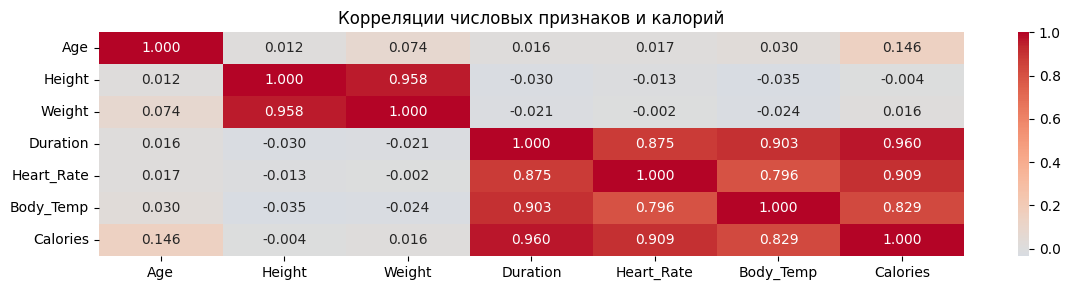

In [13]:
pearson_corr = train_df[numeric_cols + [target_col]].corr()

print('Матрица корреляций:')
display(pearson_corr)

plt.figure(figsize=(12, 3))
sns.heatmap(pearson_corr, annot=True, fmt='.3f', cmap='coolwarm', center=0)
plt.title('Корреляции числовых признаков и калорий')
plt.tight_layout()
plt.show()

Матрица корреляции подтверждает выводы выше: длительность, пульс и темп. тела
прямо положительно связаны с затраченными калориями, слабее влияние возраста.
Также между собой связаны рост и вес, скорелированы пульс, темп и длительность.

In [14]:
numeric_anomalies = []

for col in numeric_cols:
    col_vals = train_df[col].dropna()
    lower, upper = np.percentile(col_vals, [25, 75])
    iqr_count = ((col_vals < lower) | (col_vals > upper)).sum()

    z_scores = np.abs(stats.zscore(col_vals))  # type: ignore
    z_count = (z_scores > 3).sum()

    numeric_anomalies.append(
        {
            'feature': col,
            'iqr_outliers': int(iqr_count),
            'z_outliers': int(z_count),
            'n': int(len(col_vals)),
            'iqr_ratio': float(iqr_count) / len(col_vals),
            'z_ratio': float(z_count) / len(col_vals),
        }
    )

anomalies_df = pd.DataFrame(numeric_anomalies).sort_values('iqr_ratio', ascending=False)

print('Топ признаков по % выбросов за интерквартильный размах:')
display(anomalies_df)

Топ признаков по % выбросов за интерквартильный размах:


,feature,iqr_outliers,z_outliers,n,iqr_ratio,z_ratio
0,Age,357274,0,750000,0.476365,0.000000
2,Weight,352005,104,750000,0.469340,0.000139
1,Height,351705,38,750000,0.468940,0.000051
3,Duration,336714,0,750000,0.448952,0.000000
4,Heart_Rate,334296,175,750000,0.445728,0.000233
5,Body_Temp,294220,3368,750000,0.392293,0.004491


In [15]:
missing_summary = pd.DataFrame(
    {
        'feature': train_df.columns,
        'missing': [train_df[col].isna().sum() for col in train_df.columns],
        'missing_ratio': [train_df[col].isna().mean() for col in train_df.columns],
    }
).sort_values('missing', ascending=False)

display(missing_summary)

,feature,missing,missing_ratio
0,id,0,0.0
1,Sex,0,0.0
2,Age,0,0.0
3,Height,0,0.0
4,Weight,0,0.0
5,Duration,0,0.0
6,Heart_Rate,0,0.0
7,Body_Temp,0,0.0
8,Calories,0,0.0


## Разделение данных

Используется случайный train/val split (80/20), так как:
- наблюдения независимы, без времени
- отдельный test предоставлен соревнованием

In [16]:
train_part, val_part = train_test_split(
    train_df,
    test_size=0.2,
    random_state=RANDOM_STATE,
)
train_part.shape, val_part.shape, test_df.shape

((600000, 9), (150000, 9), (250000, 8))

## LightAutoML

Попробую 2 конфигурации:
1. TabularAutoML - классический пресет для табличных данных, который строит
ансамбль из нескольких моделей и их предсказания взвешенным усреднением с
подбором весов методом покоординатного спуска под целевую метрику
2. TabularUtilizedAutoML - старается эффективно потратить заданный timeout, чтобы
за отведенное время перебрать больше настроек и комбинаций моделей

Параметры обучения:
- кросс-валидация cv=5
- ограничение времени timeout = 3 часа
- пул алгоритмов: все стандратные, т.е. Linear, LightGBM, CatBoost, XGBoost

In [17]:
task = Task(name='reg', loss='mse', metric='mse', greater_is_better=False)

CV = 5
TIMEOUT = int(1.5 * 60 * 60)

automl_1 = TabularAutoML(
    task=task,
    timeout=TIMEOUT,
    reader_params={'cv': CV, 'random_state': RANDOM_STATE},
)
roles = {
    'target': target_col,
    'drop': ['id'],
    'category': categorical_cols,
}

automl_1.fit_predict(train_part, roles=roles, verbose=1)
val_pred_1 = automl_1.predict(val_part)

[00:16:47] Stdout logging level is INFO.
[00:16:47] Copying TaskTimer may affect the parent PipelineTimer, so copy will create new unlimited TaskTimer
[00:16:47] Task: reg

[00:16:47] Start automl preset with listed constraints:
[00:16:47] - time: 5400.00 seconds
[00:16:47] - CPU: 4 cores
[00:16:47] - memory: 16 GB

[00:16:47] Train data shape: (600000, 9)

[00:16:51] Layer 1 train process start. Time left 5395.94 secs
[00:16:51] Start fitting Lvl_0_Pipe_0_Mod_0_LinearL2 ...
[00:16:56] Fitting Lvl_0_Pipe_0_Mod_0_LinearL2 finished. score = -123.370273400975
[00:16:56] Lvl_0_Pipe_0_Mod_0_LinearL2 fitting and predicting completed
[00:16:56] Time left 5391.07 secs

[00:17:00] Selector_LightGBM fitting and predicting completed
[00:17:00] Start fitting Lvl_0_Pipe_1_Mod_0_LightGBM ...
[00:17:19] Fitting Lvl_0_Pipe_1_Mod_0_LightGBM finished. score = -17.317175262773986
[00:17:19] Lvl_0_Pipe_1_Mod_0_LightGBM fitting and predicting completed
[00:17:19] Start hyperparameters optimization for Lvl_

Optimization Progress:  68%|██████▊   | 69/101 [05:02<02:20,  4.38s/it, best_trial=52, best_value=-16.9]

[00:22:22] Hyperparameters optimization for Lvl_0_Pipe_1_Mod_1_Tuned_LightGBM completed
[00:22:22] Start fitting Lvl_0_Pipe_1_Mod_1_Tuned_LightGBM ...


[00:22:50] Fitting Lvl_0_Pipe_1_Mod_1_Tuned_LightGBM finished. score = -17.272024709204587
[00:22:50] Lvl_0_Pipe_1_Mod_1_Tuned_LightGBM fitting and predicting completed
[00:22:50] Start fitting Lvl_0_Pipe_1_Mod_2_CatBoost ...
[00:26:11] Fitting Lvl_0_Pipe_1_Mod_2_CatBoost finished. score = -18.280770805935628
[00:26:11] Lvl_0_Pipe_1_Mod_2_CatBoost fitting and predicting completed
[00:26:11] Start hyperparameters optimization for Lvl_0_Pipe_1_Mod_3_Tuned_CatBoost ... Time budget is 300.00 secs


Optimization Progress:   9%|▉         | 9/101 [05:38<57:35, 37.56s/it, best_trial=8, best_value=-18]    

[00:31:49] Hyperparameters optimization for Lvl_0_Pipe_1_Mod_3_Tuned_CatBoost completed
[00:31:49] Start fitting Lvl_0_Pipe_1_Mod_3_Tuned_CatBoost ...


[00:36:24] Fitting Lvl_0_Pipe_1_Mod_3_Tuned_CatBoost finished. score = -18.299654308255818
[00:36:24] Lvl_0_Pipe_1_Mod_3_Tuned_CatBoost fitting and predicting completed
[00:36:24] Time left 4223.48 secs

[00:36:24] Layer 1 training completed.

[00:36:24] Blending: optimization starts with equal weights. Score = -21.4128988
[00:36:25] Blending: iteration 0: score = -17.0647407, weights = [0.         0.3980863  0.3407812  0.15453534 0.10659712]
[00:36:25] Blending: iteration 1: score = -17.0621222, weights = [0.         0.32824972 0.41136748 0.15903002 0.10135276]
[00:36:26] Blending: iteration 2: score = -17.0619707, weights = [0.         0.31094125 0.42848852 0.1613342  0.099236  ]
[00:36:27] Blending: iteration 3: score = -17.0619582, weights = [0.         0.30751044 0.43180352 0.1629947  0.09769125]
[00:36:28] Blending: iteration 4: score = -17.0619520, weights = [0.         0.30687267 0.4323559  0.16439988 0.09637147]
[00:36:28] Blending: best score = -17.0619520, best weights = [0.

In [18]:
print('Ансамбль после обучения:', automl_1.create_model_str_desc())

rmsle_1 = root_mean_squared_log_error(val_part[target_col], val_pred_1.data[:, 0])
print('RMSLE после обучения:', rmsle_1)

Ансамбль после обучения: Final prediction for new objects (level 0) = 
	 0.30687 * (5 averaged models Lvl_0_Pipe_1_Mod_0_LightGBM) +
	 0.43236 * (5 averaged models Lvl_0_Pipe_1_Mod_1_Tuned_LightGBM) +
	 0.16440 * (5 averaged models Lvl_0_Pipe_1_Mod_2_CatBoost) +
	 0.09637 * (5 averaged models Lvl_0_Pipe_1_Mod_3_Tuned_CatBoost) 
RMSLE после обучения: 0.06922452617739104


In [19]:
automl_2 = TabularUtilizedAutoML(
    task=task,
    timeout=TIMEOUT,
    reader_params={'cv': CV, 'random_state': RANDOM_STATE},
)

automl_2.fit_predict(train_part, roles=roles, verbose=1)

[00:36:32] Start automl utilizator with listed constraints:
[00:36:32] - time: 5400.00 seconds
[00:36:32] - CPU: 4 cores
[00:36:32] - memory: 16 GB

[00:36:32] If one preset completes earlier, next preset configuration will be started

[00:36:32] ==================================================
[00:36:32] Start 0 automl preset configuration:
[00:36:32] d:\GitHub\itmo-automl\.venv\Lib\site-packages\lightautoml\automl\presets\tabular_configs\conf_0_sel_type_0.yml, random state: {'reader_params': {'random_state': 42}, 'nn_params': {'random_state': 42}, 'general_params': {'return_all_predictions': False}}
[00:36:32] Stdout logging level is INFO.
[00:36:32] Task: reg

[00:36:32] Start automl preset with listed constraints:
[00:36:32] - time: 5400.00 seconds
[00:36:32] - CPU: 4 cores
[00:36:32] - memory: 16 GB

[00:36:32] Train data shape: (600000, 9)

[00:36:37] Layer 1 train process start. Time left 5394.83 secs
[00:36:37] Start fitting Lvl_0_Pipe_0_Mod_0_LinearL2 ...
[00:36:43] Fitting 

Optimization Progress:  51%|█████▏    | 52/101 [05:04<04:46,  5.85s/it, best_trial=21, best_value=-12.6]

[00:42:18] Hyperparameters optimization for Lvl_0_Pipe_1_Mod_1_Tuned_LightGBM completed
[00:42:19] Start fitting Lvl_0_Pipe_1_Mod_1_Tuned_LightGBM ...


[00:42:48] Fitting Lvl_0_Pipe_1_Mod_1_Tuned_LightGBM finished. score = -12.879748997136806
[00:42:48] Lvl_0_Pipe_1_Mod_1_Tuned_LightGBM fitting and predicting completed
[00:42:48] Start fitting Lvl_0_Pipe_1_Mod_2_CatBoost ...
[00:46:12] Fitting Lvl_0_Pipe_1_Mod_2_CatBoost finished. score = -13.803197423136696
[00:46:12] Lvl_0_Pipe_1_Mod_2_CatBoost fitting and predicting completed
[00:46:12] Start hyperparameters optimization for Lvl_0_Pipe_1_Mod_3_Tuned_CatBoost ... Time budget is 300.00 secs


Optimization Progress:   9%|▉         | 9/101 [05:23<55:05, 35.93s/it, best_trial=4, best_value=-13.7]  

...

[01:40:24] Fitting Lvl_0_Pipe_1_Mod_1_Tuned_LightGBM finished. score = -17.377107749023008
[01:40:24] Lvl_0_Pipe_1_Mod_1_Tuned_LightGBM fitting and predicting completed
[01:40:24] Start fitting Lvl_0_Pipe_1_Mod_2_CatBoost ...
[01:43:37] Fitting Lvl_0_Pipe_1_Mod_2_CatBoost finished. score = -18.339011913570094
[01:43:37] Lvl_0_Pipe_1_Mod_2_CatBoost fitting and predicting completed
[01:43:37] Start hyperparameters optimization for Lvl_0_Pipe_1_Mod_3_Tuned_CatBoost ... Time budget is 300.00 secs


Optimization Progress:   9%|▉         | 9/101 [05:28<56:01, 36.53s/it, best_trial=3, best_value=-18]    

[01:49:06] Hyperparameters optimization for Lvl_0_Pipe_1_Mod_3_Tuned_CatBoost completed
[01:49:06] Start fitting Lvl_0_Pipe_1_Mod_3_Tuned_CatBoost ...


[01:53:32] Fitting Lvl_0_Pipe_1_Mod_3_Tuned_CatBoost finished. score = -18.23782280680621
[01:53:32] Lvl_0_Pipe_1_Mod_3_Tuned_CatBoost fitting and predicting completed
[01:53:32] Time left 780.06 secs

[01:53:32] Layer 1 training completed.

[01:53:32] Blending: optimization starts with equal weights. Score = -21.4376343
[01:53:33] Blending: iteration 0: score = -17.1080457, weights = [0.         0.39361164 0.33304352 0.13937703 0.13396782]
[01:53:33] Blending: iteration 1: score = -17.1063602, weights = [0.         0.34891474 0.37809026 0.12838309 0.14461192]
[01:53:34] Blending: iteration 2: score = -17.1059720, weights = [0.         0.34425238 0.38327888 0.11759091 0.15487783]
[01:53:35] Blending: iteration 3: score = -17.1056869, weights = [0.         0.34393752 0.3841223  0.10802828 0.16391185]
[01:53:36] Blending: iteration 4: score = -17.1054693, weights = [0.         0.3440155  0.384494   0.09961652 0.17187391]
[01:53:36] Blending: best score = -17.1054693, best weights = [0.  

array([[ 23.735806],
       [ 66.51097 ],
       [ 86.478096],
       ...,
       [193.77551 ],
       [ 82.54765 ],
       [ 38.97255 ]], dtype=float32)

In [20]:
print('Ансамбль после обучения:', automl_2.create_model_str_desc())

val_pred_2 = automl_2.predict(val_part)
rmsle_2 = root_mean_squared_log_error(val_part[target_col], val_pred_2.data[:, 0])
print('RMSLE после обучения:', rmsle_2)

Ансамбль после обучения: Final prediction for new objects = 
	1.00000 * 1 averaged models with config = "d:\GitHub\itmo-automl\.venv\Lib\site-packages\lightautoml\automl\presets\tabular_configs\conf_0_sel_type_0.yml" and different CV random_states. Their structures: 

	    Model #0.
		Final prediction for new objects (level 0) = 
			 0.31667 * (5 averaged models Lvl_0_Pipe_1_Mod_0_LightGBM) +
			 0.40016 * (5 averaged models Lvl_0_Pipe_1_Mod_1_Tuned_LightGBM) +
			 0.10867 * (5 averaged models Lvl_0_Pipe_1_Mod_2_CatBoost) +
			 0.17450 * (5 averaged models Lvl_0_Pipe_1_Mod_3_Tuned_CatBoost) 



RMSLE после обучения: 0.06061932207556604


In [21]:
models = {
    'TabularAutoML': automl_1,
    'TabularUtilizedAutoML': automl_2,
}

for name, model in models.items():
    test_preds = model.predict(test_df.drop(columns=['id']))
    test_preds = test_preds.data[:, 0]

    submission = pd.DataFrame({'id': test_df['id'], 'Calories': test_preds})
    submission.to_csv(f'./submissions/{name}.csv', index=False)

## Собственный pipeline

In [22]:
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
categorical_pipeline = Pipeline([('ohe', ohe)])
numeric_pipeline = Pipeline([('scaler', StandardScaler())])

preprocessor = ColumnTransformer(
    [
        ('num', numeric_pipeline, numeric_cols),
        ('cat', categorical_pipeline, categorical_cols),
    ]
)

preprocessor.fit(train_part.drop(columns=[target_col, 'id']))

X_train = train_part.drop(columns=[target_col, 'id'])
y_train = train_part[target_col]

X_val = val_part.drop(columns=[target_col, 'id'])
y_val = val_part[target_col]

In [23]:
kf = KFold(n_splits=CV, shuffle=True, random_state=RANDOM_STATE)


def objective_lightgbm(trial) -> float:
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000, step=50),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'num_leaves': trial.suggest_int('num_leaves', 20, 256),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'random_state': RANDOM_STATE,
        'verbosity': -1,
    }

    rmsle_scores = []
    for train_idx, valid_idx in kf.split(X_train):
        X_trn, X_val = X_train.iloc[train_idx], X_train.iloc[valid_idx]
        y_trn, y_val = y_train.iloc[train_idx], y_train.iloc[valid_idx]

        model = LGBMRegressor(**params)
        pipe = Pipeline([('prep', preprocessor), ('model', model)])
        pipe.fit(X_trn, y_trn)

        preds = np.maximum(pipe.predict(X_val), 0)
        rmsle_scores.append(root_mean_squared_log_error(y_val, preds))

    return float(np.mean(rmsle_scores))


study_lightgbm = optuna.create_study(
    direction='minimize', sampler=TPESampler(seed=RANDOM_STATE)
)
study_lightgbm.optimize(objective_lightgbm, timeout=TIMEOUT, show_progress_bar=True)

print('RMSLE после обучения:', study_lightgbm.best_value)
print('Оптимальные параметры:', study_lightgbm.best_params)

Best trial: 0. Best value: 0.0671622:    0%|          | 00:15/1:30:00

[I 2025-12-26 01:54:11,288] Trial 0 finished with value: 0.06716216962061702 and parameters: {'n_estimators': 450, 'learning_rate': 0.22648248189516848, 'max_depth': 12, 'num_leaves': 161, 'min_child_samples': 19, 'subsample': 0.5779972601681014, 'colsample_bytree': 0.5290418060840998}. Best is trial 0 with value: 0.06716216962061702.


Best trial: 1. Best value: 0.0647984:    1%|          | 00:34/1:30:00

[I 2025-12-26 01:54:30,258] Trial 1 finished with value: 0.06479842855721833 and parameters: {'n_estimators': 900, 'learning_rate': 0.030834348179355788, 'max_depth': 12, 'num_leaves': 24, 'min_child_samples': 98, 'subsample': 0.9162213204002109, 'colsample_bytree': 0.6061695553391381}. Best is trial 1 with value: 0.06479842855721833.


Best trial: 1. Best value: 0.0647984:    1%|          | 00:42/1:30:00

...

[I 2025-12-26 03:23:09,920] Trial 158 finished with value: 0.06137295223766552 and parameters: {'n_estimators': 1000, 'learning_rate': 0.028074341853746985, 'max_depth': 15, 'num_leaves': 255, 'min_child_samples': 11, 'subsample': 0.7792594650230037, 'colsample_bytree': 0.8031807891689453}. Best is trial 131 with value: 0.061048855605432474.


Best trial: 131. Best value: 0.0610489:  100%|█████████▉| 1:29:52/1:30:00

[I 2025-12-26 03:23:48,568] Trial 159 finished with value: 0.06129852698858864 and parameters: {'n_estimators': 1000, 'learning_rate': 0.02549337850414332, 'max_depth': 15, 'num_leaves': 248, 'min_child_samples': 10, 'subsample': 0.7542843938669131, 'colsample_bytree': 0.8144134971511675}. Best is trial 131 with value: 0.061048855605432474.


Best trial: 131. Best value: 0.0610489:  100%|██████████| 1:30:36/1:30:00

[I 2025-12-26 03:24:31,950] Trial 160 finished with value: 0.06133286212306059 and parameters: {'n_estimators': 1000, 'learning_rate': 0.021342236837402603, 'max_depth': 14, 'num_leaves': 249, 'min_child_samples': 15, 'subsample': 0.7694347944163866, 'colsample_bytree': 0.7999679392296499}. Best is trial 131 with value: 0.061048855605432474.
RMSLE после обучения: 0.061048855605432474
Оптимальные параметры: {'n_estimators': 1000, 'learning_rate': 0.01656531506825938, 'max_depth': 13, 'num_leaves': 248, 'min_child_samples': 6, 'subsample': 0.7237093670943449, 'colsample_bytree': 0.8069013367088312}


In [24]:
def objective_catboost(trial) -> float:
    params = {
        'iterations': trial.suggest_int('iterations', 100, 1000, step=50),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.3, log=True),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-2, 10, log=True),
        'random_seed': RANDOM_STATE,
        'verbose': False,
    }

    rmsle_scores = []
    for train_idx, valid_idx in kf.split(X_train):
        X_trn, X_val = X_train.iloc[train_idx], X_train.iloc[valid_idx]
        y_trn, y_val = y_train.iloc[train_idx], y_train.iloc[valid_idx]

        X_trn_processed = preprocessor.fit_transform(X_trn)
        X_val_processed = preprocessor.transform(X_val)

        model = CatBoostRegressor(**params)
        model.fit(X_trn_processed, y_trn)

        preds = np.maximum(model.predict(X_val_processed), 0)
        rmsle_scores.append(root_mean_squared_log_error(y_val, preds))

    return float(np.mean(rmsle_scores))


study_catboost = optuna.create_study(
    direction='minimize', sampler=TPESampler(seed=RANDOM_STATE)
)
study_catboost.optimize(objective_catboost, timeout=TIMEOUT, show_progress_bar=True)

print('RMSLE после обучения:', study_catboost.best_value)
print('Оптимальные параметры:', study_catboost.best_params)

[I 2025-12-26 03:24:31,971] A new study created in memory with name: no-name-6f3f0a8c-5341-4815-84d8-5ffe2ec7d19b
Best trial: 0. Best value: 0.0616539:    1%|          | 00:52/1:30:00

[I 2025-12-26 03:25:24,407] Trial 0 finished with value: 0.06165393633352967 and parameters: {'iterations': 450, 'learning_rate': 0.22648248189516848, 'depth': 9, 'l2_leaf_reg': 0.6251373574521749}. Best is trial 0 with value: 0.06165393633352967.


Best trial: 0. Best value: 0.0616539:    1%|▏         | 01:11/1:30:00

[I 2025-12-26 03:25:43,798] Trial 1 finished with value: 0.8122448052889837 and parameters: {'iterations': 200, 'learning_rate': 0.0024345423962016913, 'depth': 4, 'l2_leaf_reg': 3.9676050770529883}. Best is trial 0 with value: 0.06165393633352967.


Best trial: 0. Best value: 0.0616539:    2%|▏         | 01:59/1:30:00

...

[I 2025-12-26 04:51:42,078] Trial 55 finished with value: 0.0607611099656335 and parameters: {'iterations': 950, 'learning_rate': 0.062431106351749886, 'depth': 9, 'l2_leaf_reg': 3.607825384200945}. Best is trial 36 with value: 0.060591890037194826.


Best trial: 36. Best value: 0.0605919:   99%|█████████▊| 1:28:46/1:30:00

[I 2025-12-26 04:53:18,442] Trial 56 finished with value: 0.06097825880930523 and parameters: {'iterations': 950, 'learning_rate': 0.09638593913513793, 'depth': 8, 'l2_leaf_reg': 1.0679708385659485}. Best is trial 36 with value: 0.060591890037194826.


Best trial: 36. Best value: 0.0605919:  100%|██████████| 1:30:21/1:30:00

[I 2025-12-26 04:54:53,555] Trial 57 finished with value: 0.06117463080751316 and parameters: {'iterations': 850, 'learning_rate': 0.1901530801509356, 'depth': 9, 'l2_leaf_reg': 0.5379486131859408}. Best is trial 36 with value: 0.060591890037194826.
RMSLE после обучения: 0.060591890037194826
Оптимальные параметры: {'iterations': 850, 'learning_rate': 0.06034633078605103, 'depth': 10, 'l2_leaf_reg': 0.04848610267325308}


In [25]:
def objective_xgboost(trial) -> float:
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000, step=50),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 4, 10),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-2, 10, log=True),
        'random_state': RANDOM_STATE,
        'verbosity': 0,
    }

    rmsle_scores = []
    for train_idx, valid_idx in kf.split(X_train):
        X_trn, X_val = X_train.iloc[train_idx], X_train.iloc[valid_idx]
        y_trn, y_val = y_train.iloc[train_idx], y_train.iloc[valid_idx]

        X_tr_p = preprocessor.transform(X_trn)
        X_va_p = preprocessor.transform(X_val)

        model = XGBRegressor(**params)
        model.fit(X_tr_p, y_trn)

        preds = np.maximum(model.predict(X_va_p), 0)
        rmsle_scores.append(root_mean_squared_log_error(y_val, preds))

    return float(np.mean(rmsle_scores))


study_xgboost = optuna.create_study(
    direction='minimize', sampler=TPESampler(seed=RANDOM_STATE)
)
study_xgboost.optimize(objective_xgboost, timeout=TIMEOUT, show_progress_bar=True)

print('RMSLE после обучения:', study_xgboost.best_value)
print('Оптимальные параметры:', study_xgboost.best_params)

[I 2025-12-26 04:54:53,576] A new study created in memory with name: no-name-1328c9f6-ca62-46b3-8073-629da04cf9b4
Best trial: 0. Best value: 0.0628874:    0%|          | 00:20/1:30:00

[I 2025-12-26 04:55:14,130] Trial 0 finished with value: 0.06288743448711769 and parameters: {'n_estimators': 450, 'learning_rate': 0.22648248189516848, 'max_depth': 9, 'reg_lambda': 0.6251373574521749}. Best is trial 0 with value: 0.06288743448711769.


Best trial: 0. Best value: 0.0628874:    0%|          | 00:26/1:30:00

[I 2025-12-26 04:55:20,001] Trial 1 finished with value: 0.7932055262449402 and parameters: {'n_estimators': 200, 'learning_rate': 0.0024345423962016913, 'max_depth': 4, 'reg_lambda': 3.9676050770529883}. Best is trial 0 with value: 0.06288743448711769.


Best trial: 0. Best value: 0.0628874:    1%|          | 00:41/1:30:00

...

[I 2025-12-26 06:23:36,002] Trial 169 finished with value: 0.0606106664681898 and parameters: {'n_estimators': 750, 'learning_rate': 0.013697292684510615, 'max_depth': 10, 'reg_lambda': 0.6427202231590031}. Best is trial 115 with value: 0.06057297276095338.


Best trial: 115. Best value: 0.060573:   99%|█████████▉| 1:29:16/1:30:00

[I 2025-12-26 06:24:10,450] Trial 170 finished with value: 0.06255673435312452 and parameters: {'n_estimators': 700, 'learning_rate': 0.16837126927176144, 'max_depth': 10, 'reg_lambda': 1.3468549181577107}. Best is trial 115 with value: 0.06057297276095338.


Best trial: 115. Best value: 0.060573:  100%|██████████| 1:30:10/1:30:00

[I 2025-12-26 06:25:03,930] Trial 171 finished with value: 0.5587980236984106 and parameters: {'n_estimators': 700, 'learning_rate': 0.0015837887751952177, 'max_depth': 10, 'reg_lambda': 0.6333803670353753}. Best is trial 115 with value: 0.06057297276095338.
RMSLE после обучения: 0.06057297276095338
Оптимальные параметры: {'n_estimators': 700, 'learning_rate': 0.015926804203765847, 'max_depth': 10, 'reg_lambda': 1.112369174167143}


In [26]:
results = []

best_lightgbm = LGBMRegressor(**study_lightgbm.best_params, random_state=RANDOM_STATE)
pipe_lightgbm = Pipeline([('prep', preprocessor), ('model', best_lightgbm)])
pipe_lightgbm.fit(X_train, y_train)

val_preds_lightgbm = np.maximum(pipe_lightgbm.predict(X_val), 0)
rmsle_lightgbm = root_mean_squared_log_error(y_val, val_preds_lightgbm)
results.append({'model': 'LGB_Optuna_CV', 'rmsle_val': rmsle_lightgbm})
print('LGB RMSLE:', rmsle_lightgbm)

LGB RMSLE: 0.060653177236986835


In [27]:
best_catboost = CatBoostRegressor(
    **study_catboost.best_params, verbose=0, random_seed=RANDOM_STATE
)
X_train_processed = preprocessor.fit_transform(X_train)
best_catboost.fit(X_train_processed, y_train)

X_processed = preprocessor.transform(X_val)
val_preds_cat = np.maximum(best_catboost.predict(X_processed), 0)
rmsle_cat = root_mean_squared_log_error(y_val, val_preds_cat)
results.append({'model': 'CatBoost_Optuna_CV', 'rmsle_val': rmsle_cat})
print('CatBoost RMSLE:', rmsle_cat)

CatBoost RMSLE: 0.06049924689629486


In [28]:
best_xgboost = XGBRegressor(
    **study_xgboost.best_params, verbosity=0, random_state=RANDOM_STATE
)
pipe_xgboost = Pipeline([('prep', preprocessor), ('model', best_xgboost)])
pipe_xgboost.fit(X_train, y_train)

val_preds_xgb = np.maximum(pipe_xgboost.predict(X_val), 0)
rmsle_xgb = root_mean_squared_log_error(y_val, val_preds_xgb)
results.append({'model': 'XGB_Optuna_CV', 'rmsle_val': rmsle_xgb})
print('XGB RMSLE:', rmsle_xgb)

XGB RMSLE: 0.060443441089944594


In [29]:
results.append({'model': 'TabularAutoML', 'rmsle_val': float(rmsle_1)})
results.append({'model': 'TabularUtilizedAutoML', 'rmsle_val': float(rmsle_2)})

results_df = pd.DataFrame(results).sort_values('rmsle_val')
display(results_df)

,model,rmsle_val
2,XGB_Optuna_CV,0.060443
1,CatBoost_Optuna_CV,0.060499
4,TabularUtilizedAutoML,0.060619
0,LGB_Optuna_CV,0.060653
3,TabularAutoML,0.069225


In [30]:
class SimpleCatPredictor:
    def __init__(self, model, preprocessor):
        self.model = model
        self.preprocessor = preprocessor

    def predict(self, X):
        X_processed = self.preprocessor.transform(X)
        return np.maximum(self.model.predict(X_processed), 0)


models_preds = {
    'LGBMRegressor': pipe_lightgbm,
    'CatBoostRegressor': SimpleCatPredictor(best_catboost, preprocessor),
    'XGBRegressor': pipe_xgboost,
}

for name, model in models_preds.items():
    test_preds = model.predict(test_df.drop(columns=['id']))
    test_preds = np.maximum(test_preds, 0)

    submission = pd.DataFrame({'id': test_df['id'], 'Calories': test_preds})
    submission.to_csv(f'./submissions/{name}.csv', index=False)